# Regression

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats 
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("permit_table_with_postal.csv")

# Definition of problematic codes
problem_postal_codes = ['M1L', 'M1S', 'M2M', 'M6M', 'M9N']
problem_structure_types = ['10', '106', '11', '124', '130', '131', '136', '16', '166', '168', '184', '193', '27', '4', '52', '65', '94', '96']

# Preparation for Hypotheses 1 and 3 , Binary Logistic Regression
#  Filter only the 'Approved' (21.0) and 'Cancelled/Expired' (32.0) statuses
df_binary = df[df['status_id'].isin([21.0, 32.0])].copy()

#  Create the binary dependent variable (0 or 1)
# 1 if status is 21.0 (Approved), 0 otherwise (Not Approved/Cancelled)
df_binary['is_approved'] = np.where(df_binary['status_id'] == 21.0, 1, 0)

### Hypothesis 1


 H1: LOGISTIC REGRESSION TEST RESULTS
                           Logit Regression Results                           
Dep. Variable:            is_approved   No. Observations:                  867
Model:                          Logit   Df Residuals:                      849
Method:                           MLE   Df Model:                           17
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.01283
Time:                        14:23:53   Log-Likelihood:                -592.09
converged:                       True   LL-Null:                       -599.79
Covariance Type:            nonrobust   LLR p-value:                    0.5670
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4055      0.913     -0.444      0.657      -2.195       1.384
P_M2N          0.1919      0.959      0.200      0.841      -1.687       2.071
P_M4P        

/var/folders/zl/mx83d0611fj7wq1b9jmvsxnm0000gn/T/ipykernel_82677/2124328851.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


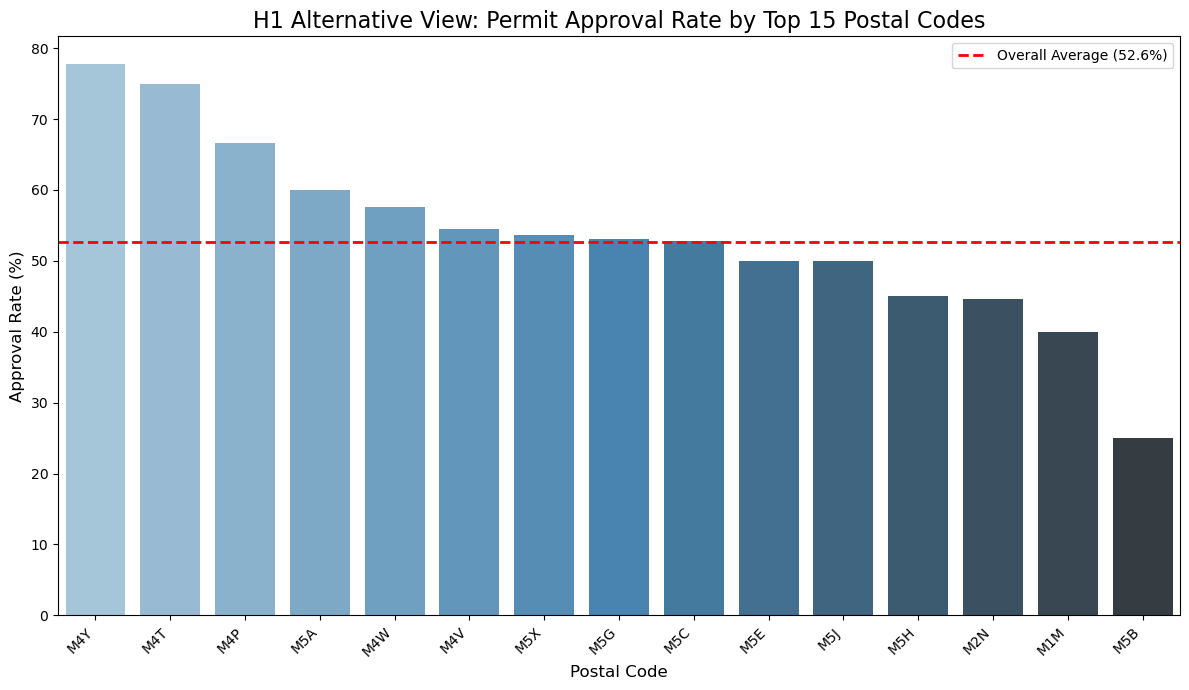

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("permit_table_with_postal.csv")
# Data Cleaning and Preparation for H1

# Problematic codes (sparse categories) that must be removed for model convergence
problem_postal_codes = ['M1L', 'M1S', 'M2M', 'M6M', 'M9N']

# Filter only Approved (21.0) and Cancelled/Expired (32.0)
df_h1 = df[df['status_id'].isin([21.0, 32.0])].copy()
df_h1['is_approved'] = np.where(df_h1['status_id'] == 21.0, 1, 0)

# Remove problematic postal codes
df_h1 = df_h1[~df_h1['postal'].isin(problem_postal_codes)].copy()

# Create postal code dummy variables
postal_dummies_h1 = pd.get_dummies(df_h1['postal'].astype(str), prefix='P', drop_first=True)

# Define X and Y, and explicitly cast them to float
X_h1 = sm.add_constant(postal_dummies_h1, prepend=True).astype(float)
y_h1 = df_h1['is_approved'].astype(float)

#  Execution of the Test Logistic Regression and Printing Summary

logit_model_h1 = sm.Logit(y_h1, X_h1)
# Fit the model (disp=False suppresses optimization output)
result_h1 = logit_model_h1.fit(disp=False)

# Clean print header
print("\n H1: LOGISTIC REGRESSION TEST RESULTS")
print(result_h1.summary())

#  Data Preparation and Printing of Bar Chart

# Calculate the overall average approval rate for comparison line
overall_avg_approval_rate = df_h1['is_approved'].mean() * 100

# Identify the top 15 most frequent postal codes
top_n = 15
top_postal_codes = df_h1['postal'].value_counts().nlargest(top_n).index

# Calculate the approval rate (mean of 'is_approved') for these top postal codes
approval_rates_h1 = df_h1[df_h1['postal'].isin(top_postal_codes)].groupby('postal')['is_approved'].mean().sort_values(ascending=False) * 100

# Convert to DataFrame for plotting
df_rates = approval_rates_h1.reset_index()
df_rates.columns = ['Postal Code', 'Approval Rate (%)']

# Clean print header
print(f"\n H1: APPROVAL RATE BAR CHART (Top {top_n} Postal Codes) ")
print(f"Overall Average Approval Rate: {overall_avg_approval_rate:.1f}%")
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Postal Code', 
    y='Approval Rate (%)', 
    data=df_rates, 
    palette='Blues_d'
)
# Add the overall average line
plt.axhline(
    overall_avg_approval_rate, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Overall Average ({overall_avg_approval_rate:.1f}%)'
)
plt.title(f'H1 Alternative View: Permit Approval Rate by Top {top_n} Postal Codes', fontsize=16)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xlabel('Postal Code', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# Display the graph in your VS Code output
plt.show()

### Hypothesis 2


 H2: CHI-SQUARED TEST RESULTS (Location vs. Status) 
Chi-square value (χ²): 47.4576
Degrees of freedom (dof): 44
p-value: 0.3335857526

 H2: STACKED BAR CHART (Top 10 Postal Codes Status Distribution) 


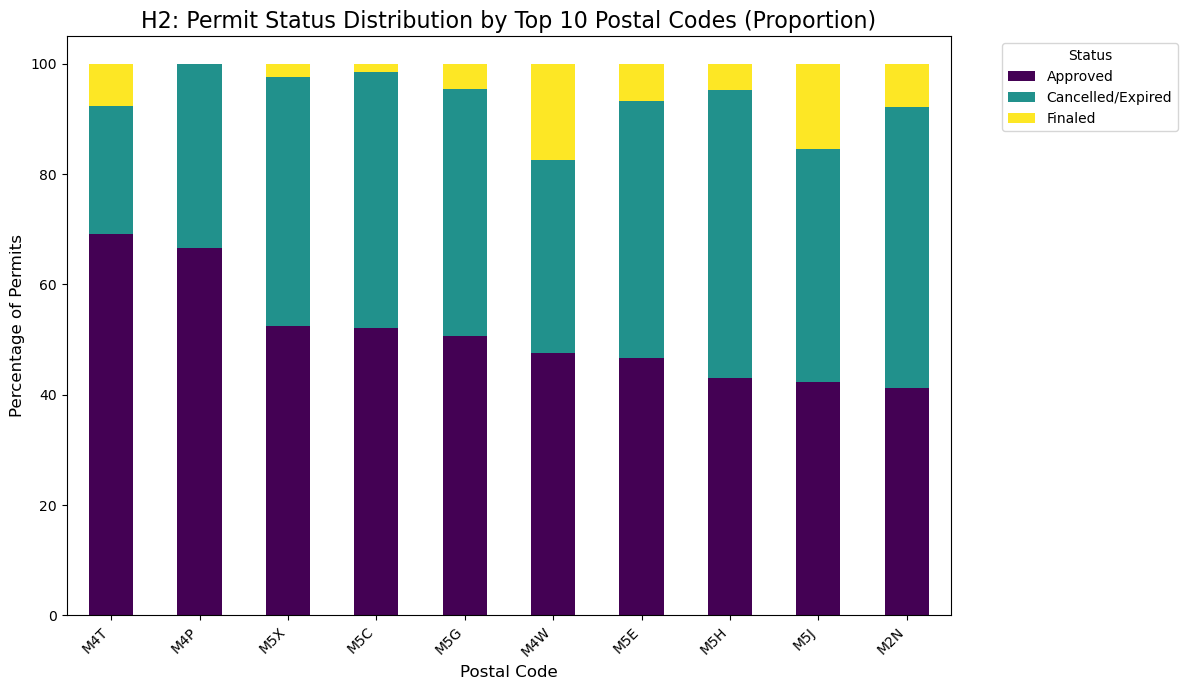

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("permit_table_with_postal.csv")
# Data Preparation for H2 Multi-class Status

# Select top statuses for a robust test
# 21.0 = Approved, 32.0 = Cancelled/Expired, 44.0 = Finaled

df_h2_test = df[df['status_id'].isin([21.0, 32.0, 44.0])].copy()

# Create descriptive status labels
df_h2_test['status_label'] = df_h2_test['status_id'].astype(int).astype(str).map({
    '21': 'Approved',
    '32': 'Cancelled/Expired',
    '44': 'Finaled'
})
# Create the Contingency Table (Crosstab)
ct_h2 = pd.crosstab(df_h2_test['postal'], df_h2_test['status_label'])

# 2. Execution of the Chi-Squared Test and Printing Summary

chi2, p_h2, dof, expected = stats.chi2_contingency(ct_h2)

# Clean print header
print("\n H2: CHI-SQUARED TEST RESULTS (Location vs. Status) ")
print(f"Chi-square value (χ²): {chi2:.4f}")
print(f"Degrees of freedom (dof): {dof}")
print(f"p-value: {p_h2:.10f}")

#  Data Preparation and Printing of Stacked Bar Chart
# Calculate percentages of each status within each postal code
ct_h2_pct = ct_h2.div(ct_h2.sum(axis=1), axis=0) * 100

# Focus on the top 10 postal codes by volume for a cleaner visualization
top_n = 10
top_postal_codes = df_h2_test['postal'].value_counts().nlargest(top_n).index
ct_h2_pct_top = ct_h2_pct.loc[top_postal_codes].sort_values('Approved', ascending=False)

# Clean print header
print(f"\n H2: STACKED BAR CHART (Top {top_n} Postal Codes Status Distribution) ")

plt.figure(figsize=(12, 7))
ct_h2_pct_top.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')

plt.title(f'H2: Permit Status Distribution by Top {top_n} Postal Codes (Proportion)', fontsize=16)
plt.ylabel('Percentage of Permits', fontsize=12)
plt.xlabel('Postal Code', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the graph in your VS Code output
plt.show()

### Hypothesis 3


 H3: LOGISTIC REGRESSION TEST RESULTS Structure Type vs. Approval 
                           Logit Regression Results                           
Dep. Variable:            is_approved   No. Observations:                  740
Model:                          Logit   Df Residuals:                      735
Method:                           MLE   Df Model:                            4
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.01493
Time:                        14:25:13   Log-Likelihood:                -504.89
converged:                       True   LL-Null:                       -512.54
Covariance Type:            nonrobust   LLR p-value:                  0.004113
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2513      0.356      0.705      0.481      -0.447       0.950
S_110          0.1815      0.402      0.452      0.651      -0.

/var/folders/zl/mx83d0611fj7wq1b9jmvsxnm0000gn/T/ipykernel_82677/3462799084.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


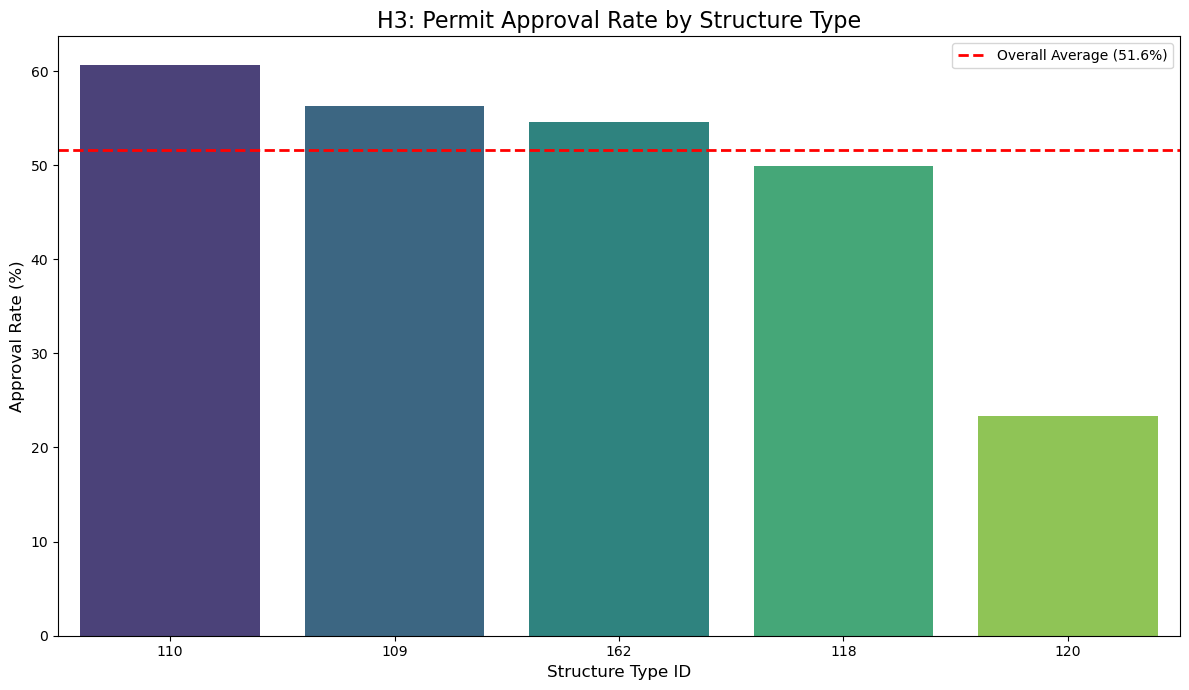

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("permit_table_with_postal.csv")
#  Data Cleaning and Preparation for H3 Stricter Filter
# Filter only Approved (21.0) and Cancelled/Expired (32.0)
df_h3 = df[df['status_id'].isin([21.0, 32.0])].copy()
df_h3['is_approved'] = np.where(df_h3['status_id'] == 21.0, 1, 0)

# Aggressively remove sparse structure types (counts < 20) to prevent model issues
min_count = 20
structure_counts = df_h3['structure_type_id'].value_counts()
common_structure_types = structure_counts[structure_counts >= min_count].index
df_h3 = df_h3[df_h3['structure_type_id'].isin(common_structure_types)].copy()

# Create structure type dummy variables (using structure_type_id 1 as reference)
structure_dummies_h3 = pd.get_dummies(df_h3['structure_type_id'].astype(str), prefix='S', drop_first=True)

# Define X and Y, and explicitly cast them to float
X_h3 = sm.add_constant(structure_dummies_h3, prepend=True).astype(float)
y_h3 = df_h3['is_approved'].astype(float)

# 2. Execution of the Test Logistic Regression and Printing Summary
logit_model_h3 = sm.Logit(y_h3, X_h3)
# Fit the model (disp=False suppresses optimization output)
result_h3 = logit_model_h3.fit(disp=False)

# Clean print header
print("\n H3: LOGISTIC REGRESSION TEST RESULTS Structure Type vs. Approval ")
print(result_h3.summary())
# 3. Data Preparation and Printing of Bar Chart (Approval Rate)
# Calculate the overall average approval rate (for comparison line)
overall_avg_approval_rate = df_h3['is_approved'].mean() * 100

# Calculate the approval rate (mean of 'is_approved') for the filtered structure types
approval_rates_h3 = df_h3.groupby('structure_type_id')['is_approved'].mean().sort_values(ascending=False) * 100

# Convert to DataFrame for plotting
df_rates = approval_rates_h3.reset_index()
df_rates.columns = ['Structure ID', 'Approval Rate (%)']
df_rates['Structure ID'] = df_rates['Structure ID'].astype(str) # Ensure plotting axis is categorical

# Clean print header
print(f"\n H3: APPROVAL RATE BAR CHART ")
print(f"Overall Average Approval Rate: {overall_avg_approval_rate:.1f}%")

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Structure ID', 
    y='Approval Rate (%)', 
    data=df_rates, 
    palette='viridis'
)
# Add the overall average line
plt.axhline(
    overall_avg_approval_rate, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Overall Average ({overall_avg_approval_rate:.1f}%)'
)
plt.title('H3: Permit Approval Rate by Structure Type', fontsize=16)
plt.ylabel('Approval Rate (%)', fontsize=12)
plt.xlabel('Structure Type ID', fontsize=12)
plt.xticks(rotation=0) # Keep labels horizontal since there are few categories
plt.legend()
plt.tight_layout()

# Display the graph in your VS Code output
plt.show()